In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

con = sqlite3.connect('../data/checking-logs.sqlite')

In [2]:
query = """
SELECT timestamp 
FROM checker
WHERE uid NOT LIKE 'admin_%'
"""
df_timestamp= pd.read_sql_query(query, con)
df_timestamp.head()

,timestamp
0,2020-04-17 05:19:02.744528
1,2020-04-17 05:22:35.249331
2,2020-04-17 05:22:45.549397
3,2020-04-17 05:34:14.691200
4,2020-04-17 05:34:24.422370


In [3]:
df_timestamp['date'] = pd.to_datetime(df_timestamp['timestamp']).dt.date
df_timestamp['hour'] = pd.to_datetime(df_timestamp['timestamp']).dt.hour
df_timestamp['weekday'] = pd.to_datetime(df_timestamp['timestamp']).dt.weekday
len(df_timestamp)

3207

In [4]:
df_timestamp["day_type"] = df_timestamp["weekday"].apply(lambda x: "working_day" if x in (0,1,2,3,4) else "weekend")
df_timestamp.tail()

,timestamp,date,hour,weekday,day_type
3202,2020-05-21 20:19:06.872761,2020-05-21,20,3,working_day
3203,2020-05-21 20:22:41.785725,2020-05-21,20,3,working_day
3204,2020-05-21 20:22:41.877806,2020-05-21,20,3,working_day
3205,2020-05-21 20:37:00.129678,2020-05-21,20,3,working_day
3206,2020-05-21 20:37:00.290491,2020-05-21,20,3,working_day


In [5]:
working_day = df_timestamp.loc[df_timestamp['day_type'] == 'working_day','hour']
len(working_day)

2037

In [6]:
weekend = df_timestamp.loc[df_timestamp['day_type'] == 'weekend', 'hour']
len(weekend)

1170

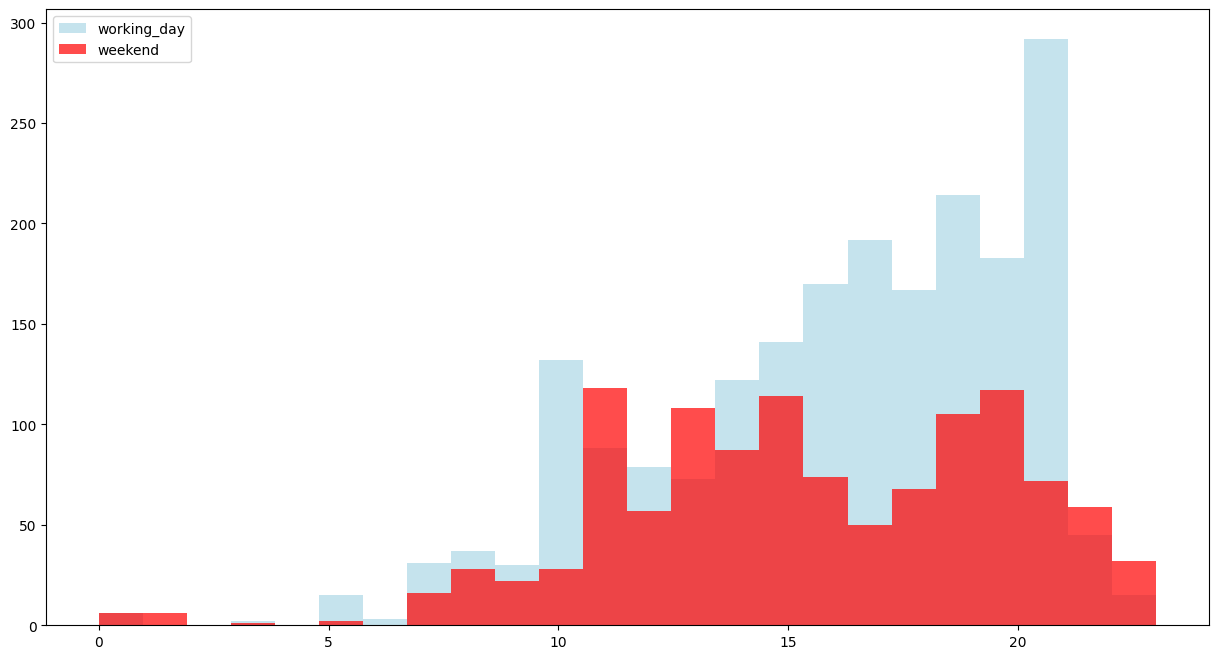

In [7]:
plt.figure(figsize=(15,8))

plt.hist(working_day, bins=24, alpha=0.7, color='lightblue', label='working_day')
plt.hist(weekend, bins=24, alpha=0.7, color='red', label='weekend')

plt.legend(loc='upper left')
plt.show()

In [8]:
con.close()

Are there hours when the total number of commits was higher on weekends than on working days?

Да. 11, 13, 22, 23.